In [1]:
#Importing necessary libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

# Impoting libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Downloading stock market data for Apple Inc. (AAPL) from Yahoo Finance
df = yf.download('AAPL', start='2020-01-01', end='2024-06-30')
df.to_csv("stock-market-data.csv", index=False)
df.head()
df.info()
df.describe()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1130 entries, 2020-01-02 to 2024-06-28
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1130 non-null   float64
 1   (High, AAPL)    1130 non-null   float64
 2   (Low, AAPL)     1130 non-null   float64
 3   (Open, AAPL)    1130 non-null   float64
 4   (Volume, AAPL)  1130 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.0 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1130.000000,1130.000000,1130.000000,1130.000000,1.130000e+03
mean,142.851922,144.353068,141.230630,142.732993,9.524801e+07
std,34.677018,34.818022,34.554878,34.684177,5.334258e+07
min,54.213600,55.211516,51.372081,55.110034,2.404830e+07
25%,123.059114,124.617326,122.070870,123.441129,6.013530e+07
50%,145.917847,147.455863,144.451302,145.696454,8.056125e+07
75%,170.004776,171.525558,168.411128,169.766729,1.119894e+08
max,215.007126,218.510038,211.365293,215.920062,4.265100e+08


In [3]:
# Create target (next day close)
df["Next_Close"] = df["Close"].shift(-1)
# Drop last row (NaN)
df = df.dropna()


In [4]:

# Features and target
X = df[["Open", "High", "Low", "Volume"]]
y = df["Next_Close"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

In [5]:
# Train Models
# ================================

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [6]:
# ================================
#Evaluation Metrics
# ================================

# Linear Regression
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

# Random Forest
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)


In [7]:
# ================================
#Print Results
# ================================

print("📊 Model Performance\n")

print("Linear Regression:")
print(f"MSE  : {lr_mse:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.2f}")

print("\nRandom Forest:")
print(f"MSE  : {rf_mse:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.2f}")

📊 Model Performance

Linear Regression:
MSE  : 7.18
RMSE : 2.68
R²   : 0.94

Random Forest:
MSE  : 28.64
RMSE : 5.35
R²   : 0.76


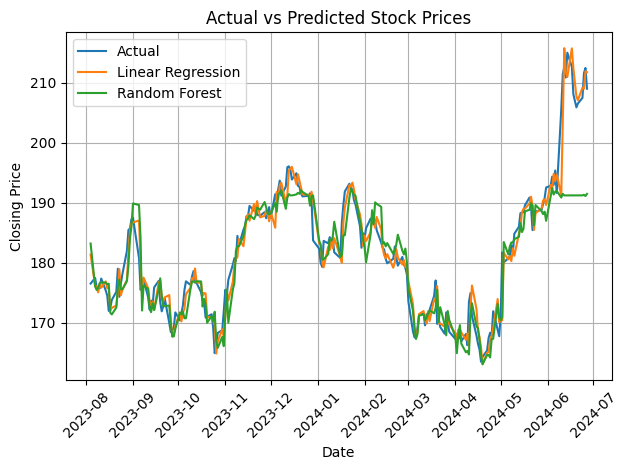

In [8]:
plt.figure()

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, lr_pred, label="Linear Regression")
plt.plot(y_test.index, rf_pred, label="Random Forest")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()